In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Grafiklerin daha şık ve profesyonel görünmesi için seaborn teması ayarlayalım
sns.set_theme(style="whitegrid")

# Bir önceki adımda ürettiğimiz ve raw klasörüne koyduğumuz veriyi okuyalım
df = pd.read_csv("../data/raw/url_dataset.csv")

print("Veri başarıyla yüklendi!\n")

# Verinin teknik özetini (röntgenini) yazdıralım
df.info()

Veri başarıyla yüklendi!

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   url                 1000 non-null   object
 1   label               1000 non-null   int64 
 2   fraud_type          1000 non-null   object
 3   has_https           1000 non-null   int64 
 4   suspicious_keyword  1000 non-null   int64 
 5   hyphen_count        1000 non-null   int64 
 6   url_length          1000 non-null   int64 
dtypes: int64(5), object(2)
memory usage: 54.8+ KB


C:\Users\emira\AppData\Local\Temp\ipykernel_13948\2533607042.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='label', y='url_length', ax=axes[1], palette='Set1')


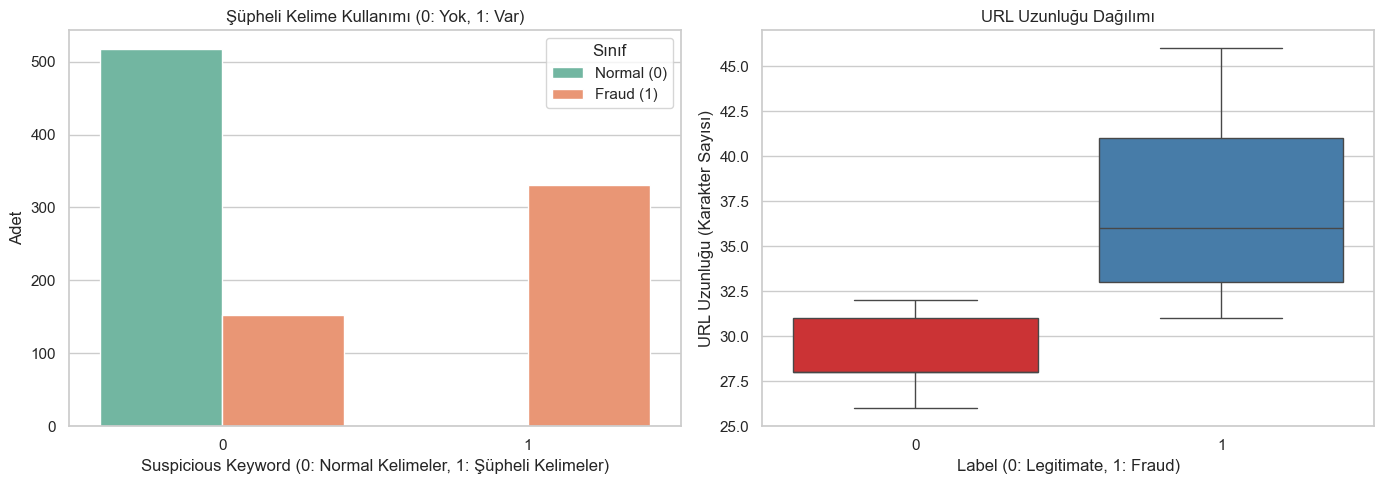

In [2]:
# Yan yana iki grafik çizmek için boş bir tuval (figure) oluşturalım
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Grafik 1: Şüpheli Kelime ve Label İlişkisi (Sütun Grafiği / Countplot)
sns.countplot(data=df, x='suspicious_keyword', hue='label', ax=axes[0], palette='Set2')
axes[0].set_title('Şüpheli Kelime Kullanımı (0: Yok, 1: Var)')
axes[0].set_xlabel('Suspicious Keyword (0: Normal Kelimeler, 1: Şüpheli Kelimeler)')
axes[0].set_ylabel('Adet')
axes[0].legend(title='Sınıf', labels=['Normal (0)', 'Fraud (1)'])

# Grafik 2: URL Uzunluğu ve Label İlişkisi (Kutu Grafiği / Boxplot)
sns.boxplot(data=df, x='label', y='url_length', ax=axes[1], palette='Set1')
axes[1].set_title('URL Uzunluğu Dağılımı')
axes[1].set_xlabel('Label (0: Legitimate, 1: Fraud)')
axes[1].set_ylabel('URL Uzunluğu (Karakter Sayısı)')

plt.tight_layout()
plt.show()

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# 1. X (Özellikler) ve y (Hedef) Ayırımı
# Model metin anlayamayacağı için 'url' ve 'fraud_type' sütunlarını çıkarıyoruz.
X = df.drop(columns=['url', 'label', 'fraud_type'])
y = df['label']

# 2. Veriyi Eğitim (%80) ve Test (%20) Olarak Bölme
# random_state=42 veriyi her seferinde aynı rastgelelikte bölmek için standart bir kullanımdır.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Modeli Tanımlama ve Eğitme (Training)
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

# 4. Sakladığımız Test Verisi Üzerinde Tahmin Yapma (Prediction)
y_pred = rf_model.predict(X_test)

print("Eğitim ve Test ayrımı tamamlandı. Model eğitildi!\n")
print("Modelin Test Verisindeki Karne (Classification Report) Sonuçları:")
print(classification_report(y_test, y_pred))

Eğitim ve Test ayrımı tamamlandı. Model eğitildi!

Modelin Test Verisindeki Karne (Classification Report) Sonuçları:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       113
           1       1.00      1.00      1.00        87

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200

